In [1]:
import pandas as pd
import numpy as np
import joblib

RANDOM_STATE = 42

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
X_train = joblib.load("../data/processed/X_train.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

print("Data loaded successfully!")

Data loaded successfully!


In [3]:
import os

print(os.getcwd())

print(os.path.exists("../data/processed/X_train.pkl"))
print(os.path.exists("../data/processed/X_test.pkl"))
print(os.path.exists("../data/processed/y_train.pkl"))
print(os.path.exists("../data/processed/y_test.pkl"))

C:\Users\malla\Desktop\Internship\road-accident-ml\notebooks
True
True
True
True


In [4]:
import joblib

X_train_processed = joblib.load("../data/processed/X_train.pkl")
X_test_processed = joblib.load("../data/processed/X_test.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

print(type(X_train_processed))
print(X_train_processed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(2400, 137)


In [5]:
# Train Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_processed, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_processed)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Logistic Regression Results")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
Accuracy : 0.3233
Precision: 0.3230
Recall   : 0.3233
F1 Score : 0.3227

Classification Report
              precision    recall  f1-score   support

           0       0.32      0.35      0.34       207
           1       0.29      0.27      0.28       196
           2       0.36      0.35      0.36       197

    accuracy                           0.32       600
   macro avg       0.32      0.32      0.32       600
weighted avg       0.32      0.32      0.32       600


Confusion Matrix
[[73 77 57]
 [80 52 64]
 [75 53 69]]


In [6]:
# Train Decision Tree

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree Results")

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
Accuracy : 0.3683
Precision: 0.3697
Recall   : 0.3683
F1 Score : 0.3542

Classification Report
              precision    recall  f1-score   support

           0       0.36      0.57      0.44       207
           1       0.37      0.22      0.28       196
           2       0.37      0.31      0.34       197

    accuracy                           0.37       600
   macro avg       0.37      0.36      0.35       600
weighted avg       0.37      0.37      0.35       600


Confusion Matrix
[[117  35  55]
 [106  43  47]
 [ 98  38  61]]


In [7]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Results")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.3517
Precision: 0.3490
Recall   : 0.3517
F1 Score : 0.3461

Classification Report
              precision    recall  f1-score   support

           0       0.37      0.48      0.41       207
           1       0.35      0.30      0.32       196
           2       0.33      0.27      0.30       197

    accuracy                           0.35       600
   macro avg       0.35      0.35      0.34       600
weighted avg       0.35      0.35      0.35       600


Confusion Matrix
[[99 54 54]
 [81 58 57]
 [91 52 54]]


In [8]:
print("Training Set Distribution:")
print(y_train.value_counts())

print("\nTesting Set Distribution:")
print(y_test.value_counts())

Training Set Distribution:
target_severity
0    827
2    788
1    785
Name: count, dtype: int64

Testing Set Distribution:
target_severity
0    207
2    197
1    196
Name: count, dtype: int64


In [9]:
import pandas as pd

print("Training Set Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Set Distribution:")
print(pd.Series(y_test).value_counts())

Training Set Distribution:
target_severity
0    827
2    788
1    785
Name: count, dtype: int64

Testing Set Distribution:
target_severity
0    207
2    197
1    196
Name: count, dtype: int64


In [10]:
from xgboost import XGBClassifier

In [11]:
# Train XGBoost Classifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

# Train
xgb.fit(X_train_processed, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test_processed)

# Evaluation
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

print("XGBoost Results")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results
Accuracy : 0.3183
Precision: 0.3160
Recall   : 0.3183
F1 Score : 0.3159

Classification Report
              precision    recall  f1-score   support

           0       0.34      0.40      0.37       207
           1       0.30      0.30      0.30       196
           2       0.30      0.25      0.27       197

    accuracy                           0.32       600
   macro avg       0.32      0.32      0.32       600
weighted avg       0.32      0.32      0.32       600


Confusion Matrix
[[82 74 51]
 [71 59 66]
 [85 62 50]]


In [12]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.368333,0.369713,0.368333,0.354209
2,Random Forest,0.351667,0.349016,0.351667,0.346123
0,Logistic Regression,0.323333,0.323031,0.323333,0.322750
3,XGBoost,0.318333,0.316007,0.318333,0.315932


In [13]:
comparison.to_csv(
    "../models/model_comparison.csv",
    index=False
)

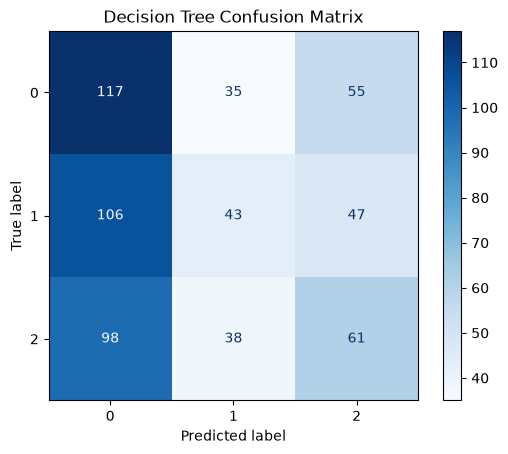

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

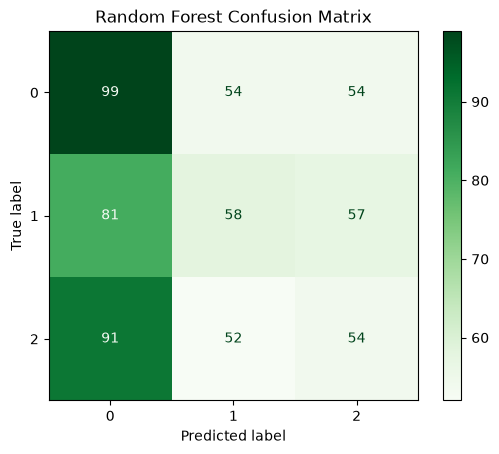

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

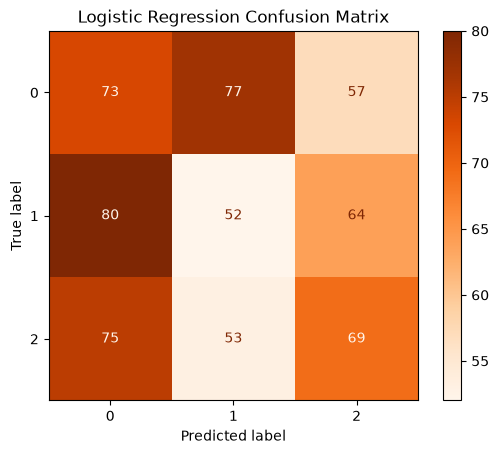

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Oranges"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

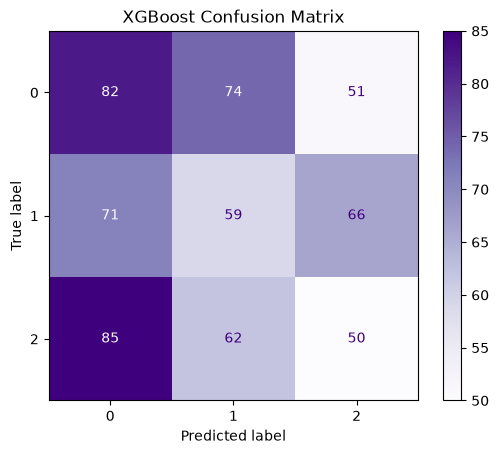

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Purples"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [18]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(dt, "../models/decision_tree_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [20]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
2,speed_limit_(km/h),0.130455
3,driver_age,0.062276
86,vehicle_type_Cycle,0.038420
107,traffic_control_presence_Police Checkpost,0.024784
125,time_of_day_Morning,0.020832
1,num_vehicles,0.020639
0,year,0.020257
87,vehicle_type_Pedestrian,0.017190
131,is_weekend_No,0.017053
95,road_type_National Highway,0.016415


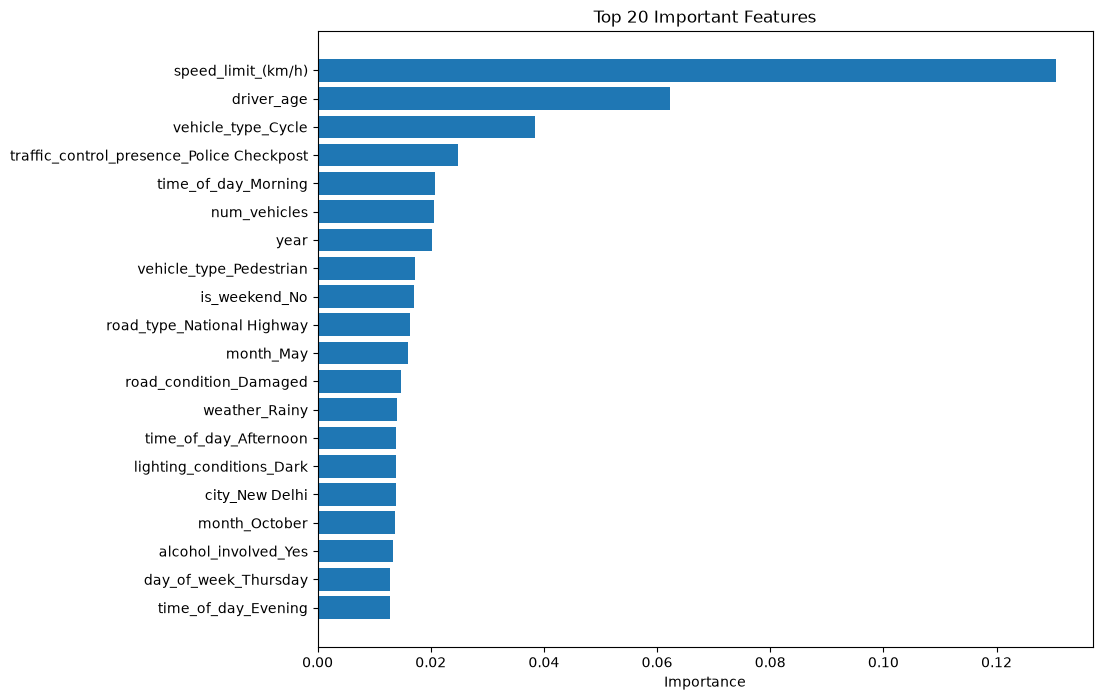

In [21]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 20 Important Features")

plt.show()

In [22]:
feature_importance.to_csv(
    "../models/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [23]:
print("MODEL TRAINING COMPLETED")


print(f"Best Model : Decision Tree")
print(f"Accuracy   : {dt_accuracy:.4f}")
print(f"Precision  : {dt_precision:.4f}")
print(f"Recall     : {dt_recall:.4f}")
print(f"F1 Score   : {dt_f1:.4f}")

print("\nGenerated Files")

print("best_model.pkl")
print("preprocessor.pkl")
print("feature_names.pkl")
print("feature_importance.csv")
print("model_comparison.csv")

MODEL TRAINING COMPLETED
Best Model : Decision Tree
Accuracy   : 0.3683
Precision  : 0.3697
Recall     : 0.3683
F1 Score   : 0.3542

Generated Files
best_model.pkl
preprocessor.pkl
feature_names.pkl
feature_importance.csv
model_comparison.csv
